# Circuit Experiments

In [ ]:
# Setup python kernel and import paths.
# The working directory should be the repo root.
# The python executable should reflect the correct conda env.
# The python search path should contain the correct import locations.
import os
import sys
os.chdir(os.getenv('REPO_ROOT'))
print(f'current working dir:  {os.getcwd()}')
print(f'python executable:    {sys.executable}')
print(f'python search path:')
for p in sys.path: print(f'  {repr(p)}')
%load_ext autoreload
%autoreload complete

In [ ]:
# Setup plotting.
import matplotlib as mpl
import matplotlib.pyplot as plt
import proplot as pplt
import seaborn as sns
import utils.plot as utp
pplt.config_inline_backend()
utp.setup_fonts(['assets/fonts'], verbose=False)
utp.setup_colors(['assets/styles/scientific.txt'], verbose=False)
display(sns.color_palette())

# Setup data tools.
import typing as T
import numpy as np
import pandas as pd
from tqdm.notebook import tqdm

# Setup interaction tools.
import ipywidgets as widgets

# Setup other libraries.
import time
import ray
ray.init(num_cpus=len(os.sched_getaffinity(0)), ignore_reinit_error=True)

[(0.10588235294117647, 0.4823529411764706, 0.7803921568627451),
 (0.8117647058823529, 0.23529411764705882, 0.2),
 (0.9058823529411765, 0.6392156862745098, 0.2549019607843137),
 (0.023529411764705882, 0.6509803921568628, 0.4235294117647059),
 (0.596078431372549, 0.33725490196078434, 0.7215686274509804),
 (0.8862745098039215, 0.44313725490196076, 0.21176470588235294),
 (0.13725490196078433, 0.7568627450980392, 0.7333333333333333),
 (0.8823529411764706, 0.38823529411764707, 0.6941176470588235),
 (0.5098039215686274, 0.7450980392156863, 0.32941176470588235),
 (0.5176470588235295, 0.5333333333333333, 0.8823529411764706)]

2025-06-19 12:33:12,828	INFO worker.py:1636 -- Started a local Ray instance.


Python version:,3.10.12
Ray version:,2.5.1


In [ ]:
# Setup project-specific imports.
import circuits as cc
from src import circuits, stimuli
from src.analyses import wave

# Half-Center Microcircuit

In [ ]:
def plot_neuron_timeseries(df: pd.DataFrame, filename='half_center/half_center', neurons=('flx', 'ext')):
  fig, axs = pplt.subplots(nrows=len(neurons), ncols=1, figwidth='310pt', refheight='28pt', share=True)

  for idx, neuron in enumerate(neurons):
    ax = axs[idx]
    ax.plot(df['t'], df[f'{neuron}.value'], c='k', clip_on=False)
    try:
      ax.plot(df['t'], df[f'{neuron}.v'], c='bll', lw=0.5, clip_on=False)
      ax.plot(df['t'], df[f'{neuron}.a'], c='rll', lw=0.5, clip_on=False)
      ax.plot(df['t'], df[f'{neuron}.x'], c='xll', lw=0.5, clip_on=False)
    except:
      pass
    
  axs.format(xloc='none', yloc=('outward', 5), xlim=(0, None), ylim=(0, 1))
  axs[-1].format(xloc=('outward', 5), xminorticks=1000, xlabel='Time [ms]', xlabelpad='-5pt')
  
  fig.savefig(f'outputs/circuits/{filename}.pdf')

In [ ]:
def osc_basic_microcircuit(T: float = 5000, dt: float = 50):
  sim = cc.Simulator(timestep=dt)
  sim.flx = cc.Oscillator(bias=0.2, xy=(5, 5), decorator='~')
  sim.ext = cc.Basic(bias=0.8, xy=(5, -5), flow='left')

  sim.flx.synapse(sim.ext, weight=-0.1, sign='-')
  sim.ext.synapse(sim.flx, weight=-0.9, sign='-')

  outputs = [f'{neuron}.{var}' for neuron in ('flx', 'ext') for var in ('value', 'v', 'a', 'x')]
  df = circuits.simulate(
    sim, T=T, fps=10, info=True, video=True, outputs=outputs,
    xlim=(-10, 10), ylim=(-10, 10), grid_lines=True, label_timestamp=True,
  )
  plot_neuron_timeseries(df, filename='half_center/osc_basic')

out = widgets.interactive(
  osc_basic_microcircuit,
  {'manual': False},
)
out

In [ ]:
def osc_osc_microcircuit(T: float = 5000, dt: float = 50, noise: bool = True, delay: bool = True):
  noise = 0.05 if noise else 0
  delay = 0.1 if delay else 0
  
  sim = cc.Simulator(timestep=dt)
  sim.flx = cc.Oscillator(bias=0, noise=noise, quiet_delay=delay, xy=(5, 5), decorator='~')
  sim.ext = cc.Oscillator(bias=0, noise=noise, quiet_delay=delay, xy=(5, -5), flow='left', decorator='~', )

  sim.flx.synapse(sim.ext, weight=-1.0, sign='-')
  sim.ext.synapse(sim.flx, weight=-1.0, sign='-')

  outputs = [f'{neuron}.{var}' for neuron in ('flx', 'ext') for var in ('value', 'v', 'a', 'x')]
  df = circuits.simulate(
    sim, T=T, fps=10, info=True, video=False, outputs=outputs,
    xlim=(-10, 10), ylim=(-10, 10), grid_lines=True, label_timestamp=True,
  )
  plot_neuron_timeseries(df, filename='half_center/osc_osc')

out = widgets.interactive(
  osc_osc_microcircuit,
  {'manual': False},
)
out

# Crustacean Pyloric Circuit

In [ ]:
def plot_pyloric_internals(
  df: pd.DataFrame,
  t='t',
  neurons=('PD', 'LP', 'PY'),
  colors=('k', 'k', 'k'),
  axs=None,
):
  if axs is None:
    _, axs = pplt.subplots(nrows=len(neurons), ncols=1, figwidth='310pt', refheight='30pt', hspace='5pt', sharex=True)
  
  # Plot each neuron on separate axis.
  ylabel_kw = dict(rotation='horizontal', va='baseline', ha='right')
  for idx, (neuron, color) in enumerate(zip(neurons, colors)):
    ax = axs[idx]
    ax.plot(df[t], df[f'pyloric.{neuron}.value'], c=color, clip_on=False)
    ax.plot(df[t], df[f'pyloric.{neuron}.v'], c='bll', lw=0.5, clip_on=False)
    ax.plot(df[t], df[f'pyloric.{neuron}.a'], c='rll', lw=0.5, clip_on=False)
    ax.plot(df[t], df[f'pyloric.{neuron}.x'], c='xll', lw=0.5, clip_on=False)
    ax.format(xloc='none', yloc='none', ylim=(-1, 1), ylabel=neuron, ylabel_kw=ylabel_kw, ylabelpad=4, ylabelcolor=color)
  return axs
  

def pyloric_circuit(T: float = 5000, dt: float = 10, bias: float = 0., info: bool = False, image: bool = False, video: bool = False, plot: bool = False, seed: int = 0, 
                    synapses: bool = True, scale: float = 1, **kwargs):
  sim = cc.Simulator(timestep=dt)
  sim.pyloric = circuits.PyloricCircuit(synapses=synapses, scale=scale)

  for neuron in ('PD', 'LP', 'PY'):
    sim.pyloric[neuron].bias += bias
  
  outputs = [f'pyloric.{neuron}.{var}' for neuron in ('PD', 'LP', 'PY') for var in ('value', 'v', 'a', 'x')]

  df = circuits.simulate(
    sim, T=T, fps=10, seed=seed, info=info, image=image, video=video, outputs=outputs, save=True, save_dir='outputs/neurons/pyloric', 
    xlim=(0, 20), ylim=(0, 20), grid_lines=True, label_timestamp=True, **kwargs,
  )
  if plot: plot_pyloric_internals(df)
  return df

out = widgets.interactive(
  pyloric_circuit,
  {'manual': False},
  T=(1_000, 30_000),
  bias=(0, 1, 0.05),
  scale=(0.5, 3.0),
  info=True,
  image=False,
  video=False,
  plot=True,
  seed=(1, 10),
)
out

## 1 Plot circuit activity

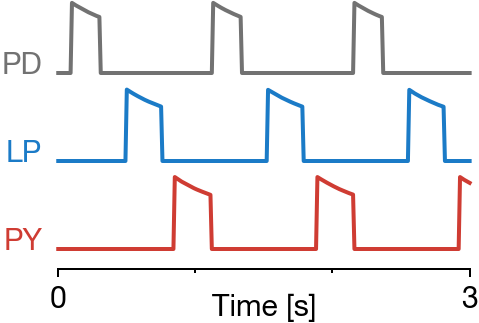

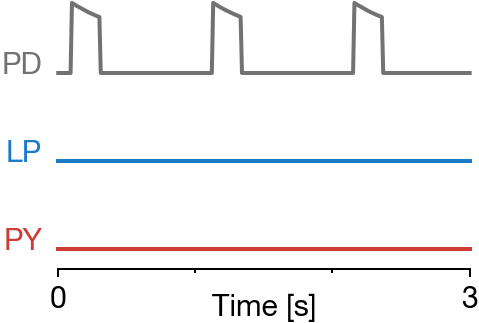

In [ ]:
def plot_pyloric_timeseries(
  df: pd.DataFrame,
  t='t',
  neurons=('PD', 'LP', 'PY'),
  colors=('x', 'b', 'r'),
  axs=None,
):
  # Plot each neuron on separate axis.
  ylabel_kw = dict(rotation='horizontal', va='baseline', ha='right', y=0)
  for idx, (neuron, color) in enumerate(zip(neurons, colors)):
    ax = axs[idx]
    ax.plot(df[t], df[f'pyloric.{neuron}.value'], c=color, clip_on=False)
    ax.format(xloc='none', yloc='none', ylim=(0, 1), ylabel=neuron, ylabel_kw=ylabel_kw, ylabelpad=4, ylabelcolor=color)
  return axs

def plot_pyloric_circuit_activity(df, name='default', t='t', tstart=700, twidth=3000, **kwargs):
  fig, axs = pplt.subplots(nrows=3, ncols=1, figwidth='120pt', refheight='18pt', hspace='4pt', sharex=True)
  df = df[(tstart <= df[t]) & (df[t] <= tstart + twidth)]
  df.loc[:, t] -= tstart
  plot_pyloric_timeseries(df, t=t, axs=axs, **kwargs)
  axs[-1].format(xloc=('outward', 5), xlabel='Time [s]', xminorticks=1000, xticks=[0, twidth], xformatter=lambda x, pos: f'{x/1000:g}', xlabelpad='-5pt')
  fig.savefig(f'outputs/circuits/pyloric/pyloric_circuit_activity_{name}.pdf')


df = pyloric_circuit(T=5000, dt=10, synapses=True)
plot_pyloric_circuit_activity(df, name='default')

df = pyloric_circuit(T=5000, dt=10, synapses=False)
plot_pyloric_circuit_activity(df, name='isolated')

## 2 Plot perturbation activity

In [ ]:
import utils.numeric as utn

def measure_perturbation_activity(temps=(10, 15, 20, 25)):
  dfs = {}
  for temp in tqdm(list(temps)):
    # scale = (10-3)/(temp-3)
    scale = np.exp(-(temp-10)/13)
    dfs[temp] = pyloric_circuit(T=5000, dt=5, scale=scale)
  return dfs

dfs = measure_perturbation_activity(temps=utn.floatrange(10, 25, 1))

In [ ]:
def plot_perturbation_activity(dfs, temps=(10, 15, 20, 25), t='t', tgap=100, twidth=3000, **kwargs):
  fig, axs = pplt.subplots(nrows=len(temps)*3, ncols=1, figwidth='100pt', refheight='12pt', sharex=True,
                           hspace=(['4pt', '4pt', '21pt']*len(temps))[:-1])
  for idx, temp in enumerate(temps):
    ax = axs[3*idx:3*(idx+1)]
    df = dfs[temp]
    # Crop data to start right before the first PD burst.
    tstart = df.loc[df['pyloric.PD.value'].ne(0).argmax(), 't'] - tgap
    df = df[(tstart <= df[t]) & (df[t] <= tstart + twidth)]
    df.loc[:, t] -= tstart
    plot_pyloric_timeseries(df, t=t, axs=ax, colors=('x', 'b', 'r'), **kwargs)
    ax[0].format(rtitle=f'Temp = {temp:g} °C')
  axs[-1].format(xloc=('outward', 5), xlabel='Time [s]', xminorticks=1000, xticks=[0, twidth], xformatter=lambda x, pos: f'{x/1000:g}', xlabelpad='-5pt')
  fig.savefig('outputs/circuits/pyloric/pyloric_perturbation_activity.pdf')

plot_perturbation_activity(dfs)

In [311]:
def measure_perturbation_stats(dfs: dict[float, pd.DataFrame], t='t'):
  data = []  # [(temp, period, frequency, duty_cycle, phase_on, phase_off) x (PD, LP, PY)]
  for temp, df in dfs.items():
    for ref in range(3):
      row = { 'temp': temp }
      for neuron in ('PD', 'LP', 'PY'):
        info = wave.measure_waveform(df, t=t, y=f'pyloric.{neuron}.value', peaks=False, ref=ref)
        assert info.stats is not None
        if neuron == 'PD':
          PD_rise0, _, PD_rise1 = info.stats.t_bounds
          PD_period = PD_rise1 - PD_rise0
        period = info.stats.T_osc / 1000
        frequency = 1 / period
        duty_cycle = info.stats.T_active / PD_period
        t_on, t_off, _ = info.stats.t_bounds
        phase_on = (t_on - PD_rise0) / PD_period
        phase_off = (t_off - PD_rise0) / PD_period
        row.update({
          f'period/{neuron}': period,
          f'frequency/{neuron}': frequency,
          f'duty_cycle/{neuron}': duty_cycle,
          f'phase_on/{neuron}': phase_on,
          f'phase_off/{neuron}': phase_off,
        })
      data.append(row)
  df = pd.DataFrame(data)
  df = df.groupby('temp').mean().reset_index()
  return df

stats = measure_perturbation_stats(dfs)
stats

,temp,period/PD,frequency/PD,duty_cycle/PD,phase_on/PD,phase_off/PD,period/LP,frequency/LP,duty_cycle/LP,phase_on/LP,phase_off/LP,period/PY,frequency/PY,duty_cycle/PY,phase_on/PY,phase_off/PY
0,10,1.006667,0.993383,0.205294,0.0,0.205294,1.006667,0.993383,0.258280,0.384103,0.642382,1.008333,0.991774,0.263238,0.746696,1.009934
1,11,0.933333,1.071456,0.205350,0.0,0.205350,0.933333,1.071477,0.258922,0.383932,0.642854,0.936667,1.067704,0.262488,0.746454,1.008942
2,12,0.865000,1.156095,0.208097,0.0,0.208097,0.865000,1.156095,0.262037,0.387292,0.649329,0.865000,1.156147,0.262026,0.747619,1.009645
3,13,0.801667,1.247477,0.207891,0.0,0.207891,0.801667,1.247412,0.261970,0.382538,0.644508,0.801667,1.247606,0.263989,0.746428,1.010417
4,14,0.743333,1.345345,0.208529,0.0,0.208529,0.743333,1.345386,0.260090,0.385676,0.645766,0.745000,1.342402,0.264565,0.744444,1.009009
5,15,0.691667,1.445800,0.209641,0.0,0.209641,0.691667,1.445851,0.260244,0.385552,0.645796,0.696667,1.435423,0.269888,0.737375,1.007264
6,16,0.641667,1.558463,0.210392,0.0,0.210392,0.641667,1.558463,0.262334,0.387011,0.649346,0.645000,1.550450,0.270147,0.737686,1.007833
7,17,0.595000,1.680672,0.210084,0.0,0.210084,0.595000,1.680672,0.260504,0.386555,0.647059,0.600000,1.666744,0.266106,0.745098,1.011204
8,18,0.548333,1.823742,0.209730,0.0,0.209730,0.550000,1.818282,0.264443,0.386016,0.650459,0.553333,1.807459,0.267445,0.744732,1.012177
9,19,0.513333,1.948093,0.214290,0.0,0.214290,0.513333,1.948093,0.262993,0.389619,0.652611,0.516667,1.935646,0.269465,0.740307,1.009772


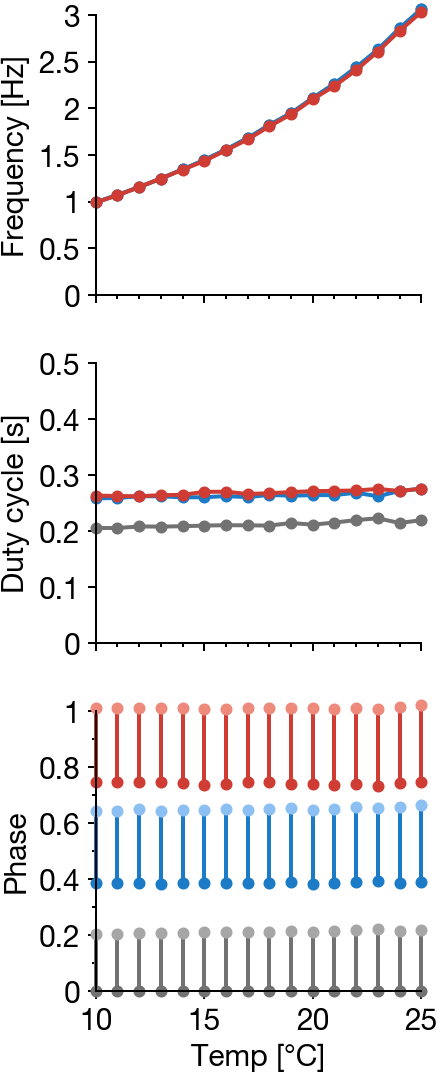

In [ ]:
def plot_perturbation_stats(df: pd.DataFrame, temp='temp', neurons=('PD', 'LP', 'PY'), colors=('x', 'b', 'r'), **kwargs):
  fig, axs = pplt.subplots(nrows=3, ncols=1, figwidth='110pt', refheight='70pt', sharex=True, hspace='17pt')

  for neuron, color in zip(neurons, colors):
    axs[0].plot(df[temp], df[f'frequency/{neuron}'], color=color, marker='.', clip_on=False)
  axs[0].format(ylabel='Frequency [Hz]', ylim=(0, 3), yticks=0.5, yminorticks=0.5, yformatter='{x:g}')

  for neuron, color in zip(neurons, colors):
    axs[1].plot(df[temp], df[f'duty_cycle/{neuron}'], color=color, marker='.', clip_on=False)
  axs[1].format(ylabel='Duty cycle [s]', ylim=(0, 0.5), yticks=0.1, yminorticks=0.1, yformatter='{x:g}')

  for neuron, color in zip(neurons, colors):
    axs[2].vlines(df[temp], df[f'phase_on/{neuron}'], df[f'phase_off/{neuron}'], color=color, clip_on=False)
    axs[2].plot(df[temp], df[f'phase_on/{neuron}'], color=color, lw=0, marker='.', edgecolor=color, clip_on=False)
    axs[2].plot(df[temp], df[f'phase_off/{neuron}'], color=f'{color}l', lw=0, marker='.',clip_on=False)
  axs[2].format(xlabel='Temp [°C]',  xformatter='{x:g}', xminorticks=1, # xlim=(10, 25), xticks=0, 
                ylabel='Phase', ylim=(0, 1), yticks=0.2, yminorticks=0.1, yformatter='{x:g}')
  
  fig.savefig('outputs/circuits/pyloric/pyloric_perturbation_stats.pdf')

plot_perturbation_stats(stats)

# Mammalian Locomotion Circuit

In [ ]:
def osc_osc_locomotion_microcircuit(T: float = 3000, dt: float = 10, seed: int = 1):  
  sim = cc.Simulator(timestep=dt)
  osc_kwargs = {
    'activation': cc.adapting,
    'adaptation_time': 500,
    'active_time': 80,
    'quiet_time': 310,
    'active_scale_pos': 0.25,
    'quiet_scale_pos': 0.04,
    'active_scale_neg': 0.9,
    'quiet_scale_neg': 1.0,
    'adaptation_scale_active_pos': 1.,
    'adaptation_scale_quiet_pos': 1.2,
    'adaptation_scale_active_neg': 1.2,
    'adaptation_scale_quiet_neg': 0.8,
    'active_stable': 1,
    'quiet_delay': 0.1,
    'quiet_stable_margin': 50,
    'noise': 0.20,
  }
  sim.flx = cc.Oscillator(bias=0, **osc_kwargs, xy=(5, 5), decorator='~')
  sim.ext = cc.Oscillator(bias=0, **osc_kwargs, xy=(5, -5), flow='left', decorator='~', )

  sim.flx.synapse(sim.ext, weight=-1.0, sign='-')
  sim.ext.synapse(sim.flx, weight=-1.0, sign='-')

  outputs = [f'{neuron}.{var}' for neuron in ('flx', 'ext') for var in ('value', 'v', 'a', 'x')]
  df = circuits.simulate(
    sim, T=T, fps=10, info=True, video=False, outputs=outputs,
    xlim=(-10, 10), ylim=(-10, 10), grid_lines=True, label_timestamp=True, seed=seed,
  )
  plot_neuron_timeseries(df, filename='half_center/osc_osc_locomotion')

out = widgets.interactive(
  osc_osc_locomotion_microcircuit,
  {'manual': False},
  dt=(0.1, 50),
  seed=(1, 10),
)
out

In [ ]:
def locomotion_circuit(T: float = 1_000, dt: float = 30, N: int = 1, start: float = 0.2, end: float = 1.0, info: bool = False, image: bool = False, video: bool = False, seed: int = 0, **kwargs):
  sim = cc.Simulator(timestep=dt)
  sim.rg = circuits.RhythmGenerationCircuit()

  stimulus = stimuli.steps(start, end, N)
  inputs = {f'rg.{command}_{side}.value': stimulus for command in ('freq', 'sync') for side in ('L', 'R')}
  outputs = (
    [f'rg.{name}.value' for name, unit in sim.rg.named_children() if isinstance(unit, cc.Unit)] + 
    [f'rg.{center}_{limb}.{var}' for center in ('flx', 'ext') for limb in ('FL', 'FR', 'HL', 'HR') for var in ('v', 'a', 'x')]
  )

  df = circuits.simulate(
    sim, T=T, fps=10, seed=seed, info=info, image=image, video=video, inputs=inputs, outputs=outputs, save=True, save_dir='outputs/neurons/locomotion', 
    xlim=(None, 0), grid_lines=True, label_timestamp=True, **kwargs, 
  )
  return df

out = widgets.interactive(
  locomotion_circuit,
  {'manual': False},
  T=(1_000, 30_000),
  dt=(1, 50),
  N=(1, 10),
  start=(0, 1, 0.05),
  end=(0, 1, 0.05),
  info=False,
  image=True,
  seed=(1, 10),
)
out

In [ ]:
def plot_locomotion_internals(
  dfs: list[pd.DataFrame],
  t='t',
  titles=[],
  orient='h',
):
  if orient == 'v':
    nrows = 5*2 + 5*1 + 1*2
    hspace = 5*['0pt', '10pt'] + 5*['10pt'] + 1*['0pt', '10pt']
    L = (0, 0)
    R = (0, 1)
    F = (0, 0)
    H = (1, 0)
  else:
    # nrows = 5*2 + 5*2 + 1*2
    # hspace = 5*['0pt', '10pt'] + 5*['0pt', '10pt'] + 1*['0pt', '10pt']
    nrows = 5*2 + 4*2
    hspace = 5*['0pt', '10pt'] + 4*['0pt', '10pt']
    L = (0, 0)
    R = (1, 0)
    F = (0, 1)
    H = (0, 0)

  def format(label: str) -> str:
    name = label.split('_')[-1]
    name = name[0].upper() + name[1:]
    return name
  
  fig, axs = pplt.subplots(nrows=nrows, ncols=2*len(dfs), figwidth='490pt', refheight='12pt', sharex=True,
                           wspace=(['0pt', '10pt']*len(dfs))[:-1], hspace=hspace[:-1])
  axs.format(ylim=(0, 1), yticks=[0, 1], yticklabels=[])
  axs[-1, 1:].format(xticklabels=[])
  axs[-1, 0].format(xlabel='Time [s]', xformatter=lambda x, pos: f'{x/1000:g}')
  ylabel_kw = dict(rotation='horizontal', va='top', ha='right', y=1)

  for idx, df in enumerate(dfs):
    row = 0
    col = 2 * idx
    if titles: axs[0, col+0].format(ltitle=f'BC = {titles[idx]:.1g}')
    
    # Plot neurons (osc, cross).
    for neuron in ('flx', 'ext', 'cross_v0d', 'cross_v3f', 'cross_v3e'):
      axs[row+F[0]+L[0], col+F[1]+L[1]].plot(df[t], df[f'rg.{neuron}_FL.value'], c='bluel', clip_on=False)
      axs[row+F[0]+R[0], col+F[1]+R[1]].plot(df[t], df[f'rg.{neuron}_FR.value'], c='blue', clip_on=False)
      axs[row+H[0]+L[0], col+H[1]+L[1]].plot(df[t], df[f'rg.{neuron}_HL.value'], c='redl', clip_on=False)
      axs[row+H[0]+R[0], col+H[1]+R[1]].plot(df[t], df[f'rg.{neuron}_HR.value'], c='red', clip_on=False)
      if col == 0: axs[row, 0].format(ylabel=format(neuron), ylabel_kw=ylabel_kw)
      row += 2
  
    # Plot neurons (diagd).
    for neuron in ('diagd_v0d', 'diagd_v0v', 'diagd_in2'):
      axs[row+F[0]+L[0], col+F[1]+L[1]].plot(df[t], df[f'rg.{neuron}_FL.value'], c='bluel', clip_on=False)
      axs[row+F[0]+R[0], col+F[1]+R[1]].plot(df[t], df[f'rg.{neuron}_FR.value'], c='blue', clip_on=False)
      if col == 0: axs[row, 0].format(ylabel=format(neuron), ylabel_kw=ylabel_kw)
      row += 1 if orient == 'v' else 2
  
    # Plot neurons (diaga).
    for neuron in ('diaga_v3a',):
      axs[row+H[0]+L[0], col+H[1]+L[1]].plot(df[t], df[f'rg.{neuron}_HL.value'], c='redl', clip_on=False)
      axs[row+H[0]+R[0], col+H[1]+R[1]].plot(df[t], df[f'rg.{neuron}_HR.value'], c='red', clip_on=False)
      if col == 0: axs[row, 0].format(ylabel=format(neuron), ylabel_kw=ylabel_kw)
      row += 1 if orient == 'v' else 2
  
    # # Plot neurons (cmd).
    # for neuron in ('freq',):
    #   axs[row+F[0]+L[0], col+F[1]+L[1]].plot(df[t], df[f'rg.{neuron}_L.value'], c='grayl', clip_on=False)
    #   axs[row+F[0]+R[0], col+F[1]+R[1]].plot(df[t], df[f'rg.{neuron}_R.value'], c='gray', clip_on=False)
    #   if col == 0: axs[row, 0].format(ylabel=format(neuron), ylabel_kw=ylabel_kw)
    #   row += 1 if orient == 'v' else 2

    # # Plot neurons (input).
    # for neuron in ('flx',):
    #   axs[row+F[0]+L[0], col+F[1]+L[1]].plot(df[t], df[f'rg.{neuron}_FL.x'], c='bluel', clip_on=False)
    #   axs[row+F[0]+R[0], col+F[1]+R[1]].plot(df[t], df[f'rg.{neuron}_FR.x'], c='blue', clip_on=False)
    #   axs[row+H[0]+L[0], col+H[1]+L[1]].plot(df[t], df[f'rg.{neuron}_HL.x'], c='redl', clip_on=False)
    #   axs[row+H[0]+R[0], col+H[1]+R[1]].plot(df[t], df[f'rg.{neuron}_HR.x'], c='red', clip_on=False)
    #   for ax in axs[row:row+2, col:col+2]:
    #     ax.axhline(0, c='k', lw=0.5, ls='--')
    #     ax.format(ylim=(-1, 1), yticks=[-1, 0, 1])
    #   if col == 0: axs[row, 0].format(ylabel=f'{format(neuron)}.x', ylabel_kw=ylabel_kw)
    #   row += 2
      
  fig.savefig(f'outputs/circuits/locomotion/locomotion_internals.pdf')

Time: 30.38097643852234


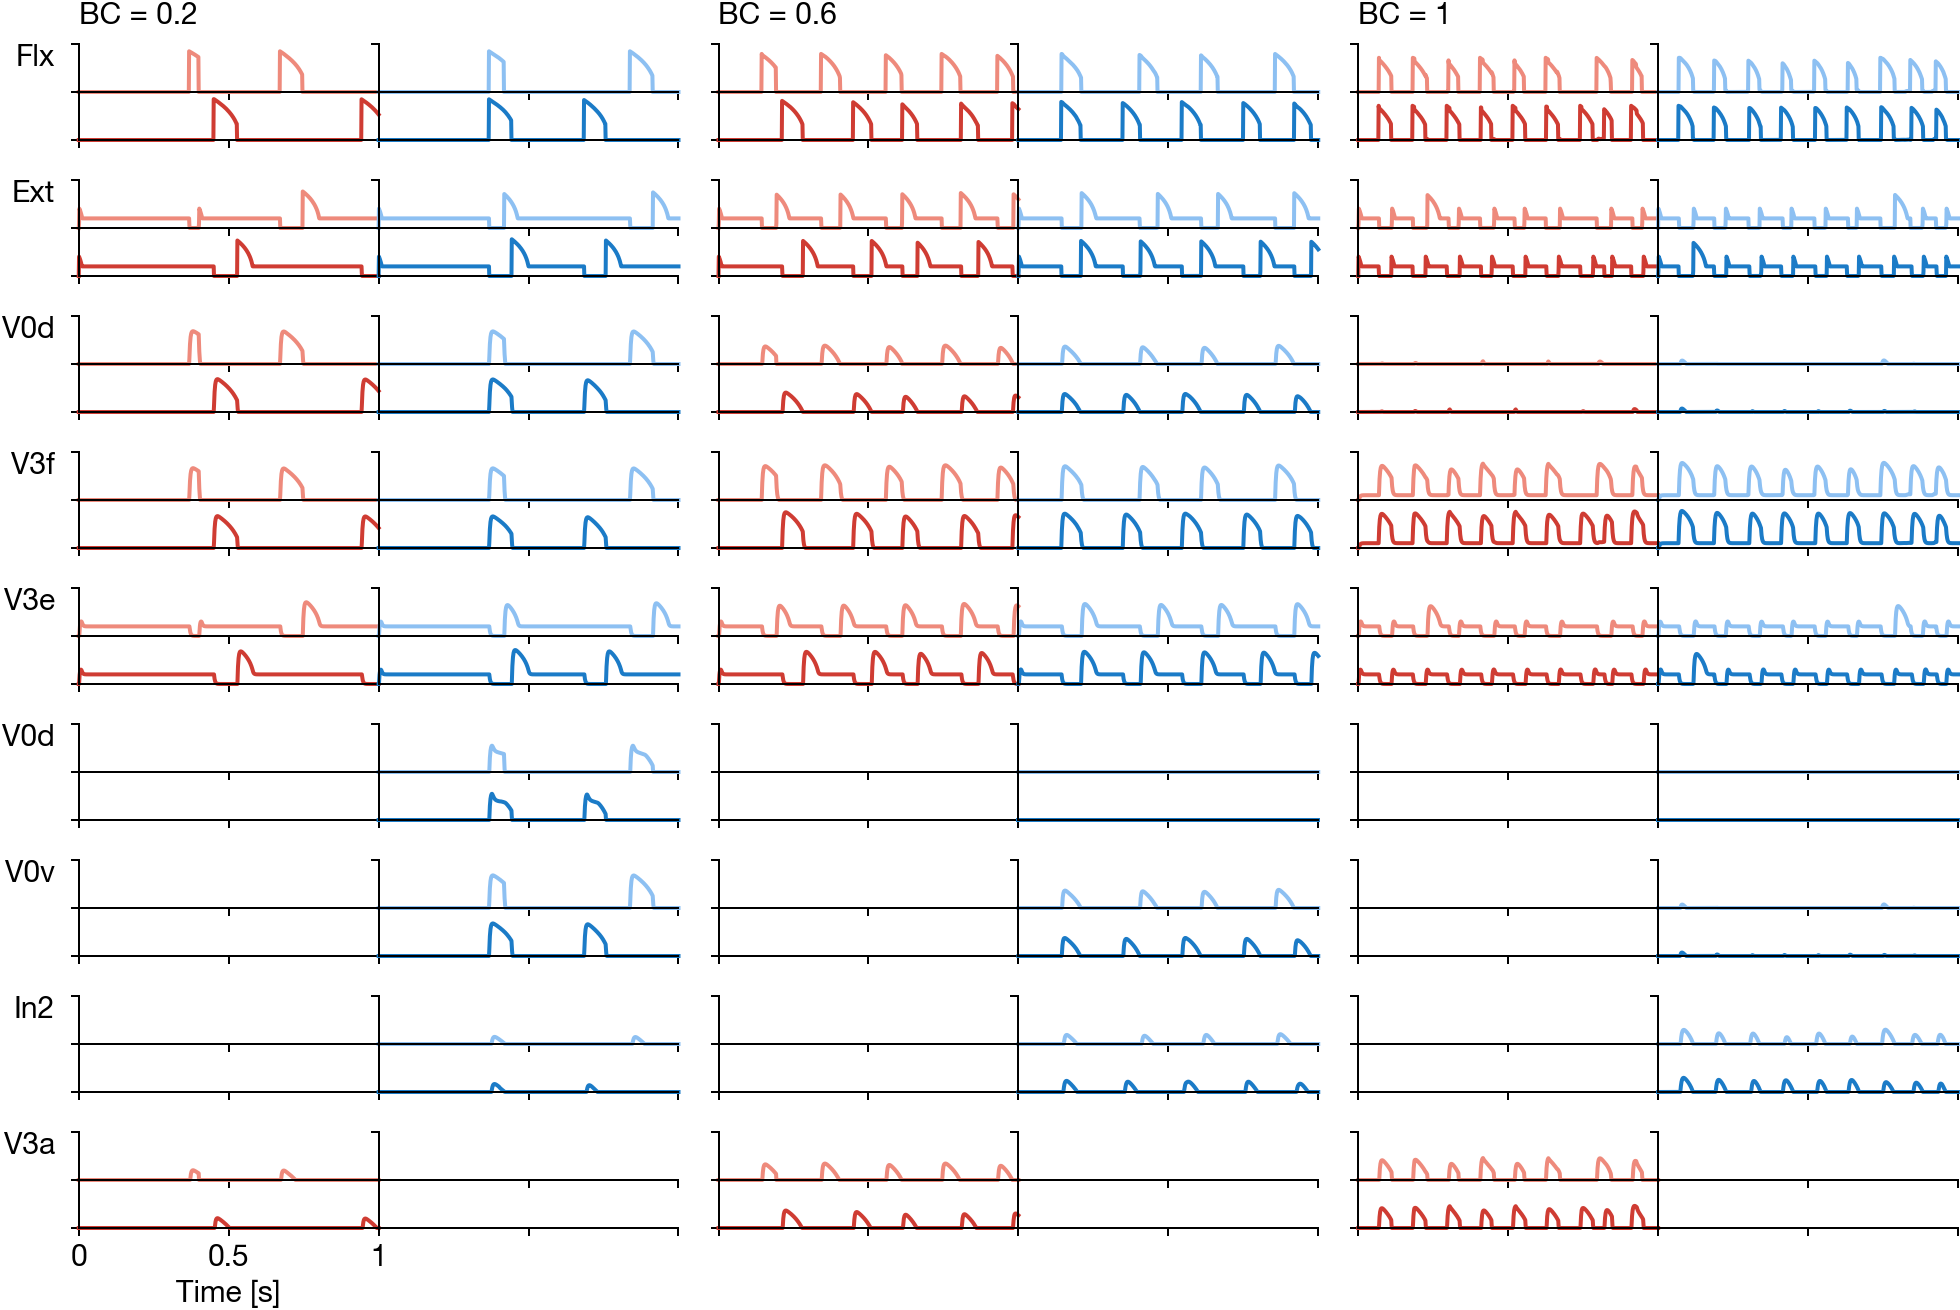

In [6]:
start_time = time.time()
dfs = [
  locomotion_circuit(T=1000, dt=1, N=1, start=0.2, seed=1),
  locomotion_circuit(T=1000, dt=1, N=1, start=0.6, seed=2),
  locomotion_circuit(T=1000, dt=1, N=1, start=1.0, seed=3),
]
print('Time:', time.time() - start_time)
plot_locomotion_internals(dfs, titles=[0.2, 0.6, 1.0], orient='h')

## 1 Plot timeseries

In [ ]:
import matplotlib.cm as mcm
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches


def plot_oscillators(
  df: pd.DataFrame,
  t='t',
  limbs=('FL', 'FR', 'HL', 'HR'),
  colors=('bluel', 'blue', 'redl', 'red'),
  ext=True,
  axs=None,
):
  if axs is None:
    _, axs = pplt.subplots(nrows=len(limbs), ncols=1, figwidth='310pt', refheight='18pt', hspace='1pt', sharex=True)
  
  # Plot each limb on separate axis.
  ylabel_kw = dict(rotation='horizontal', va='baseline', ha='right', y=0)
  for idx, (limb, color) in enumerate(zip(limbs, colors)):
    ax = axs[idx]
    ax.plot(df[t], df[f'rg.flx_{limb}.value'], c=color, clip_on=False)
    if ext: ax.plot(df[t], df[f'rg.ext_{limb}.value'], c=color, clip_on=False, alpha=0.4)
    ax.format(xloc='none', yloc='none', ylim=(0, 1), ylabel=limb, ylabel_kw=ylabel_kw, ylabelpad=4, ylabelcolor=color)
  return axs


def plot_footfalls(
  df: pd.DataFrame,
  t='t',
  limbs=('FL', 'FR', 'HL', 'HR'),
  colors=('bluel', 'blue', 'redl', 'red'),
  ref=None,
  title=None,
  axs=None,
  figwidth=1,
):
  if axs is None:
    fig, axs = pplt.subplots(nrows=len(limbs), ncols=1, figwidth='310pt', refheight='5pt', hspace='5pt', sharex=True)
  else:
    fig = axs[0].figure

  ylabel_kw = dict(rotation='horizontal', va='baseline', ha='right', y=0)
  for idx, (limb, color) in enumerate(zip(limbs, colors)):
    ax = axs[idx]    
    matrix = np.asarray(df[f'foot_{limb}']).reshape(1, -1)  # (rows=1, cols=T)
    cmap = mcolors.LinearSegmentedColormap.from_list('cmap', [(0, (1, 1, 1, 0)), (1, color)])
    ax.pcolormesh(df[t], np.arange(2), matrix[:, :-1], vmin=0, vmax=1, cmap=cmap, ec='face', edgefix=True)  # Prevent lines in pdf with `edgefix`.
    ax.format(xloc='none', yloc='none', ylabel=limb, ylabel_kw=ylabel_kw, ylabelpad=4, ylabelcolor=color)

    if ref == limb:
      intervals = wave.find_intervals(df, t=t, y=f'foot_{limb}')
      for _, row in intervals.iterrows():
        fig.add_artist(mpatches.ConnectionPatch((row[f'{t}_start'], 1), (row[f'{t}_start'], 0), 'data', 'data', axesA=axs[0], axesB=axs[-1], zorder=0, color='xl'))
        fig.add_artist(mpatches.ConnectionPatch((row[f'{t}_end'], 1), (row[f'{t}_end'], 0), 'data', 'data', axesA=axs[0], axesB=axs[-1], zorder=0, color='xl'))
  
  return ax


def plot_stimulus(
  df: pd.DataFrame,
  t='t',
  i='BC',
  xticks=5000,
  xminorticks=1000,
  ax=None,
):
  if ax is None:
    _, ax = pplt.subplots(nrows=1, ncols=1, figwidth='310pt', refheight='18pt')

  ylabel_kw = dict(rotation='horizontal', va='baseline', ha='right', y=0)
  ax.fill_between(df[t], df[i], 0, step='post', color='grayll')
  ax.format(yloc='none', ylim=(0, 1), ylabel=i, ylabel_kw=ylabel_kw, ylabelpad=4, 
            xloc='bottom', xlim=(np.floor(df[t].iloc[0] / xminorticks) * xminorticks, np.ceil(df[t].iloc[-1] / xminorticks) * xminorticks),
            xticks=xticks, xminorticks=xminorticks, xticklabels=[])
  return ax


def plot_locomotion_gaits(df: pd.DataFrame, t='t', i='BC', filename='locomotion_gaits', limbs=('FL', 'FR', 'HL', 'HR'), ref='HR',
                          subfigs_count=2, subfigs_size=3000):
  df[i] = df['rg.freq_L.value']
  for limb in limbs:
    df[f'foot_{limb}'] = (df[f'rg.flx_{limb}.value'] <= 0.1) * 1
  
  N = len(limbs)
  for idx in range(subfigs_count):
    df_subfig = df[(subfigs_size * idx <= df[t]) & (df[t] < subfigs_size * (idx+1))]
    fig, axs = pplt.subplots(nrows=2*N+1, ncols=1, figwidth='250pt', refheight='12pt', refnum=1, sharex=True,
                             hratios=[12]*N + [4]*N + [8], hspace=['3pt']*(N-1) + ['10pt'] + ['4pt']*(N-1) + ['8pt'])
    plot_oscillators(df_subfig, t=t, limbs=limbs, axs=axs[0:N], ext=False)
    plot_footfalls(df_subfig, t=t, limbs=limbs, axs=axs[N:2*N], ref=ref)
    plot_stimulus(df_subfig, t=t, i=i, ax=axs[-1])
    axs[-1].format(xformatter=lambda x, pos: f'{x/1000:g}', xticks=(idx*subfigs_size, (idx+1)*subfigs_size))
    if idx == subfigs_count - 1: axs[-1].format(xlabel='Time [s]', xlabelpad='-5pt')
      
    fig.savefig(f'outputs/circuits/locomotion/{filename}_{idx}.pdf')

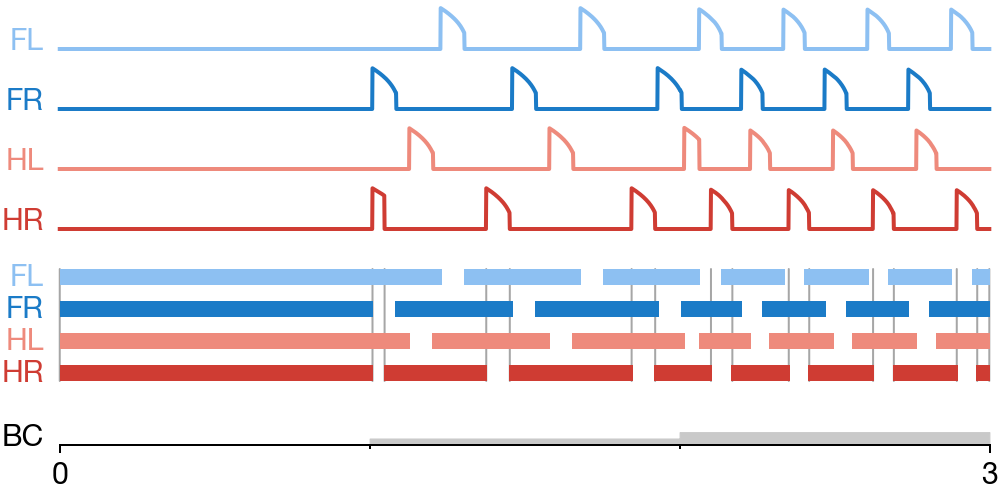

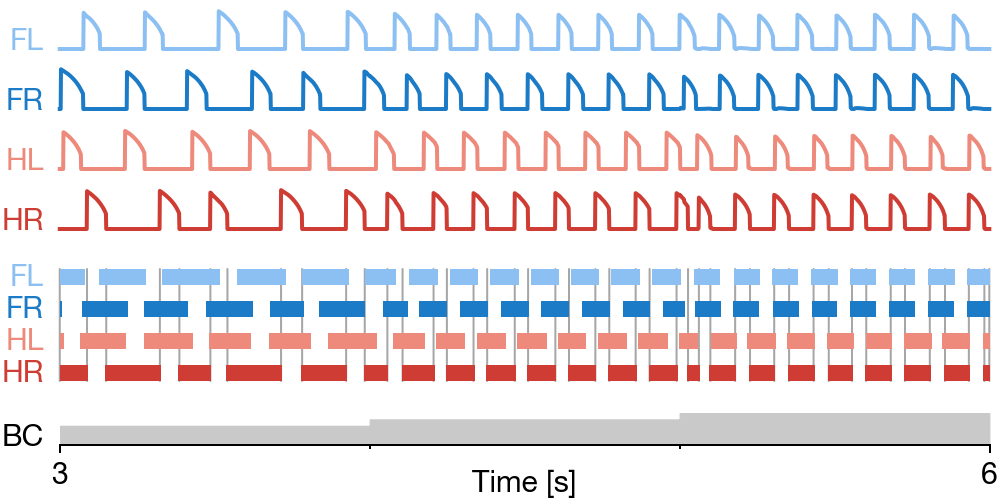

In [14]:
df = locomotion_circuit(T=6000, dt=1, N=6, start=0, end=1, seed=1)
plot_locomotion_gaits(df, subfigs_count=2)

## 2 Plot gait statistics

In [ ]:
def setup_plotting():
  utp.setup_fonts(['assets/fonts'], verbose=False)
  utp.setup_colors(['assets/styles/scientific.txt'], verbose=False)

def measure_locomotion_stats(T=4000, dt=1, N=11, start=0, end=1, t='t', i='BC', limb='HL', skip=2, repeat=5):
    @ray.remote(num_cpus=1)
    def measure_one(stim: float):
      # Must reset to use all cores: https://stackoverflow.com/questions/15639779.
      os.sched_setaffinity(0, range(os.cpu_count()))
      df = locomotion_circuit(T=T, dt=dt, N=1, start=stim, end=stim)

      try:
        # Plot waveform.
        setup_plotting()
        plot_locomotion_gaits(df, t=t, i=i, filename=f'locomotion_stats_stim={stim:.2f}', subfigs_count=1, subfigs_size=T)
        pplt.close()
      except Exception as e:
        raise RuntimeError(f'Error for stim = {stim}') from e

      # Measure waveform.
      rows = []
      for ref in range(skip, skip+repeat):
        # Need to clean up the flx signal by removing non-zero quiet phase in order to accurately
        # calculate the step period. Otherwise, there may be local peaks due to non-zero quiet phase.
        df[f'flx_{limb}'] = (df[f'rg.flx_{limb}.value'] > 0.1) * 1
        info = wave.measure_waveform(df, t=t, y=f'flx_{limb}', peaks=False, ref=ref)
        if info.stats:
          # Gather period not frequency, as it can be averaged, while frequency cannot.
          period = info.stats.T_osc / 1000
          flexion = info.stats.T_active / 1000
          extension = info.stats.T_quiet / 1000
        else:
          period = None
          flexion = None
          extension = None
        rows.append((stim, period, flexion, extension))
      return rows

    stimulus = stimuli.steps(start, end, N, width=1)
    futures = [measure_one.remote(round(stimulus(n, N), 10)) for n in range(N)]
  
    data = []
    with tqdm(total=N) as pbar:
      while futures:
        done, futures = ray.wait(futures, num_returns=1)
        data.extend(ray.get(done[0]))
        pbar.update(1)
        
    df = pd.DataFrame(data, columns=[i, 'period', 'flexion', 'extension'])
    df = df.sort_values(by=i).reset_index(drop=True)
    return df

df_raw = measure_locomotion_stats()
df_raw

  0%|          | 0/11 [00:00<?, ?it/s]

,BC,period,flexion,extension
0,0.0,NaN,NaN,NaN
1,0.0,NaN,NaN,NaN
2,0.0,NaN,NaN,NaN
3,0.0,NaN,NaN,NaN
4,0.0,NaN,NaN,NaN
5,0.1,NaN,NaN,NaN
6,0.1,NaN,NaN,NaN
7,0.1,NaN,NaN,NaN
8,0.1,NaN,NaN,NaN
9,0.1,NaN,NaN,NaN


In [10]:
df = df_raw.groupby('BC').mean().reset_index()
df['frequency'] = (1 / df['period'])
df

,BC,period,flexion,extension,frequency
0,0.0,NaN,NaN,NaN,NaN
1,0.1,NaN,NaN,NaN,NaN
2,0.2,0.4682,0.0774,0.3908,2.135839
3,0.3,0.3140,0.0752,0.2388,3.184713
4,0.4,0.2880,0.0660,0.2220,3.472222
5,0.5,0.2692,0.0612,0.2080,3.714710
6,0.6,0.1950,0.0656,0.1294,5.128205
7,0.7,0.1664,0.0566,0.1098,6.009615
8,0.8,0.1350,0.0474,0.0876,7.407407
9,0.9,0.1404,0.0502,0.0902,7.122507


In [ ]:
def plot_locomotion_stats(df: pd.DataFrame, t='t', i='BC'):
  fig, axs = pplt.subplots(nrows=1, ncols=2, refwidth='90pt', refheight='60pt', wspace='45pt')

  axs[0].plot(df[i], df['frequency'], color='k', clip_on=False)
  axs[0].format(xlabel='Brainstem command (BC)', xlim=(0, 1), xticks=0.2, xminorticks=0.1, xformatter='{x:g}',
                ylabel='Frequency [Hz]', ylim=(0, 10), yticks=2, yformatter='{x:g}')

  axs[1].plot(df[i], df['flexion'], color='k')
  axs[1].plot(df[i], df['extension'], color='xl')
  axs[1].format(xlabel='Brainstem command (BC)', xlim=(0, 1), xticks=0.2, xminorticks=0.1, xformatter='{x:g}',
                ylabel='Duration [s]', ylim=(0, 0.4), yticks=0.1, yformatter='{x:g}')
      
  fig.savefig(f'outputs/circuits/locomotion/locomotion_stats.pdf')

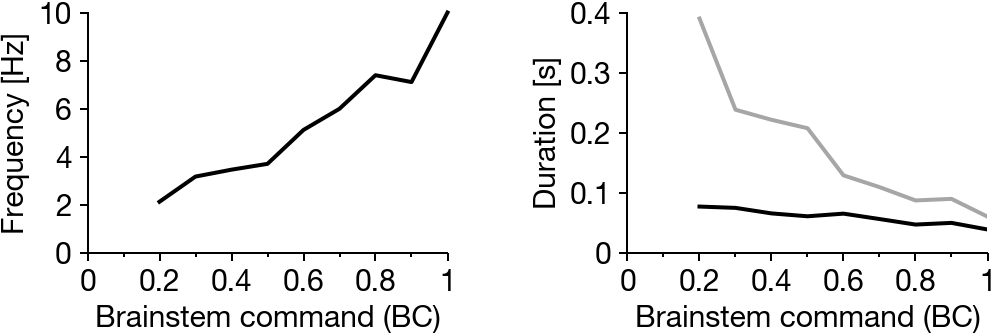

In [12]:
plot_locomotion_stats(df)